# Snake Game - Deep Reinforcement Learning Analysis

**Student:** Salvatore Ferracane    
**ID:** 2154255  
**Course:** Reinforcement Learning  
**Master Degree:** Control Systems Engineering  
*University of Padua, Italy*

---

###  Project Overview
This project investigates the capabilities and limitations of Deep Reinforcement Learning agents in the classic Snake game under varying visibility conditions.

We compare **four distinct architectures** to analyze the impact of partial observability and memory:

#### 1. Fully Observable (FO) - $7 \times 7$ Grid
* **Baseline (Heuristic):** A BFS-based solver with access to the global state. Serves as the theoretical **performance upper bound**.
* **Double DQN:** A standard CNN-based agent seeing the full board. It tests if model-free RL can approach the heuristic baseline given perfect information.

#### 2. Partially Observable (PO) - $5 \times 5$ Local View
* **Dueling DDQN:** Uses **Frame Stacking ($k=4$)** to infer velocity and direction. It represents a "reactive" approach to partial observability.
* **PPO + LSTM:** Uses **Recurrent Neural Networks (RNNs)** to maintain a long-term belief state. It aims to solve the **"Ghost Tail"** problem (collision with body parts outside the current view).

---

### Dependencies & Setup
Ensure the following libraries are installed.
*> **Note:** Training the PPO agent is computationally intensive (approx. 3 days on CPU). This notebook focuses on evaluating pre-trained weights.*

```bash
pip install numpy tensorflow matplotlib seaborn tqdm ipykernel
```

In [8]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tqdm import trange
from pathlib import Path

# Custom modules
import environments_fully_observable 
import environments_partially_observable
from baseline import BaselineAgent
from dqn_agent import DQNAgent, DQNConfig
from po_dqn_agent import PartiallyObservableDQNAgent, PODQNConfig
from ppo_agent import PPOAgent, PPOConfig

# Global seeds for reproducibility
tf.random.set_seed(0)
random.seed(0)
np.random.seed(0)

# Global configuration
SEED = 0
BOARD_SIZE = 7
MASK_SIZE = 2
N_PARALLEL_BOARDS = 1000
GAMMA = 0.9

# Output directories (centralized management)
OUTPUTS = {
    'fo_dqn': Path('results/fo_dqn'),
    'po_dqn': Path('results/po_dqn'),
    'po_safety': Path('results/po_safety'),
    'ppo': Path('results/ppo'),
    'comparison': Path('results/comparison')
}

for output_dir in OUTPUTS.values():
    output_dir.mkdir(parents=True, exist_ok=True)

print("✓ Setup complete. Output directories created.")
print(f"  - FO DQN: {OUTPUTS['fo_dqn']}")
print(f"  - PO DQN: {OUTPUTS['po_dqn']}")
print(f"  - PO Safety: {OUTPUTS['po_safety']}")
print(f"  - PPO: {OUTPUTS['ppo']}")
print(f"  - Comparison: {OUTPUTS['comparison']}")

✓ Setup complete. Output directories created.
  - FO DQN: results/fo_dqn
  - PO DQN: results/po_dqn
  - PO Safety: results/po_safety
  - PPO: results/ppo
  - Comparison: results/comparison


## Fully Observable (FO) Environment

In this section, we train a **Double DQN agent** with complete access to the $7 \times 7$ board state. The agent uses a CNN-based architecture to learn an end-to-end policy mapping global observations to actions.

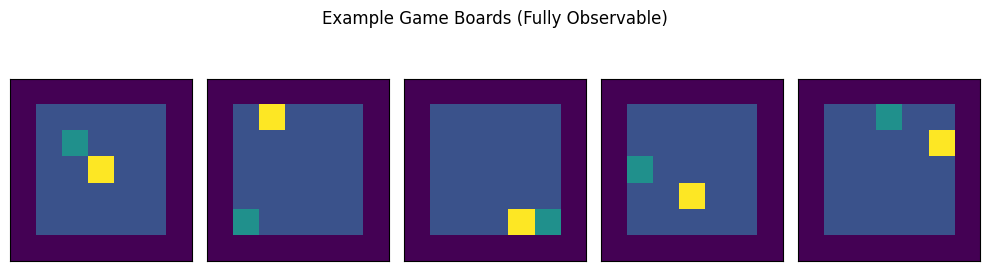

In [9]:
%matplotlib inline

def get_env_fo(n=1000):
    """Factory function to instantiate a fully observable Snake environment."""
    return environments_fully_observable.OriginalSnakeEnvironment(n, BOARD_SIZE)

# Visualize initial boards
env_fo = get_env_fo(n=100)
fig, axs = plt.subplots(1, min(len(env_fo.boards), 5), figsize=(10, 3))
for ax, board in zip(axs, env_fo.boards):
    ax.get_yaxis().set_visible(False)
    ax.get_xaxis().set_visible(False)
    ax.imshow(board, origin="lower")
plt.suptitle("Example Game Boards (Fully Observable)")
plt.tight_layout()
plt.show()

### DQN Model Configuration

Define the architecture and hyperparameters for the Double DQN agent. The CNN processes the full board state to predict action-value estimates.

In [10]:
# FO DQN Configuration
STATE_SHAPE_FO = (7, 7, 4)
N_ACTIONS = 4
FO_ITERATIONS = 10000

fo_config = DQNConfig(
    gamma=GAMMA,
    learning_rate=1e-4,
    epsilon_decay_steps=FO_ITERATIONS // 2,
    warmup_steps=1000,
    use_double_dqn=True  # Enable Double DQN for stability
)

fo_agent = DQNAgent(state_shape=STATE_SHAPE_FO, n_actions=N_ACTIONS, config=fo_config)
env_fo = get_env_fo(n=N_PARALLEL_BOARDS)

print(f"FO Agent Config:")
print(f"  State shape: {STATE_SHAPE_FO}")
print(f"  Actions: {N_ACTIONS}")
print(f"  Use Double DQN: {fo_config.use_double_dqn}")

FO Agent Config:
  State shape: (7, 7, 4)
  Actions: 4
  Use Double DQN: True


### Training Loop

Train the Double DQN agent on the fully observable environment. Metrics are collected for analysis and checkpoints are saved periodically.

In [11]:
fo_rewards_history = []

print(f"Starting FO DQN Training ({FO_ITERATIONS} iterations)...")

for iteration in trange(FO_ITERATIONS, desc="FO DQN Training"):
    metrics = fo_agent.train_on_env_step(env_fo)
    fo_rewards_history.append(metrics["mean_reward"])

    # Checkpoint every 2500 iterations
    if iteration > 0 and iteration % 2500 == 0:
        checkpoint_path = OUTPUTS['fo_dqn'] / f"dqn_fo_ckpt_{iteration}.weights.h5"
        fo_agent.online_network.save_weights(str(checkpoint_path))

# Save final weights
final_weights_path = OUTPUTS['fo_dqn'] / "dqn_fo_final.weights.h5"
fo_agent.online_network.save_weights(str(final_weights_path))
print(f"✓ Training complete. Weights saved to: {final_weights_path}")

Starting FO DQN Training (10000 iterations)...


FO DQN Training: 100%|██████████| 10000/10000 [09:39<00:00, 17.27it/s]

✓ Training complete. Weights saved to: results/fo_dqn/dqn_fo_final.weights.h5


### Heuristic Baseline

Establish a deterministic baseline using a BFS-based heuristic. This upper bound shows the theoretical maximum performance assuming perfect information.

In [13]:
# Baseline evaluation
print("Computing Heuristic Baseline...")
baseline_env = get_env_fo(n=100)
baseline_agent = BaselineAgent()
baseline_rewards = []

for _ in range(1000):
    actions = baseline_agent.select_actions(baseline_env)
    rewards = baseline_env.move(actions.reshape(-1, 1))
    baseline_rewards.append(np.mean(rewards))

fo_baseline_score = np.sum(baseline_rewards)
print(f"✓ Baseline Score: {fo_baseline_score:.2f}")

Computing Heuristic Baseline...
✓ Baseline Score: 45.46


### Performance Comparison: DQN vs Heuristic Baseline

Visualize training progress relative to the heuristic baseline. The smoothed curve shows convergence behavior.

✓ Plot saved: results/fo_dqn/fo_dqn_vs_baseline.pdf


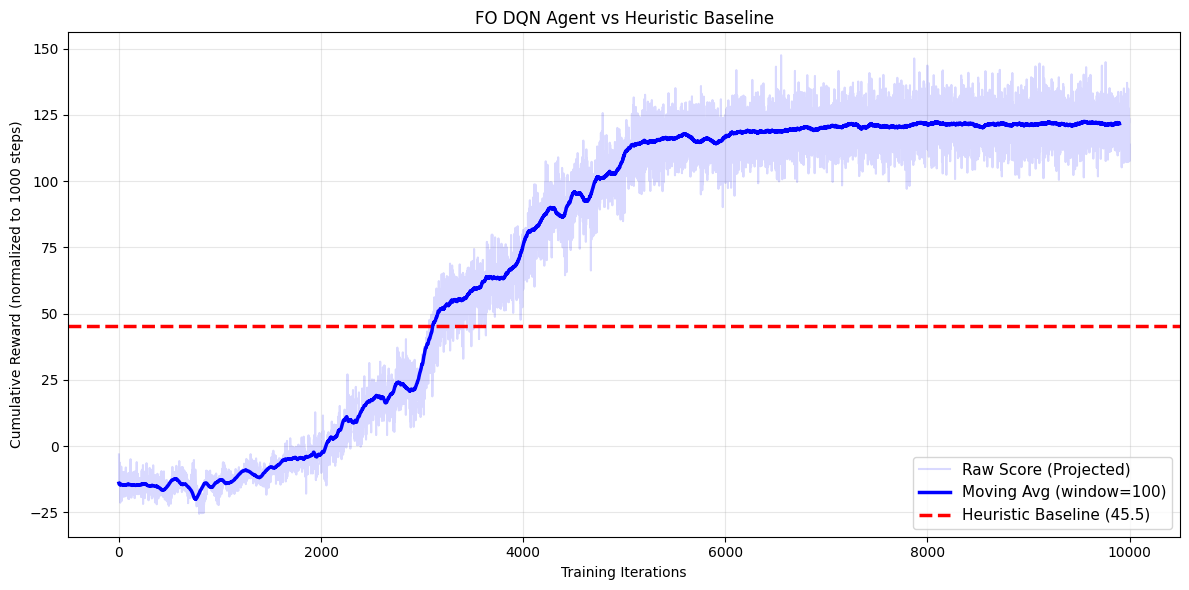

In [14]:
def plot_dqn_vs_baseline(rewards_history, baseline_score, output_path, window=100):
    """Plot DQN training progress against heuristic baseline."""
    
    # Project per-step rewards to cumulative over 1000 steps
    projected = np.array(rewards_history) * 1000
    
    # Smoothing
    if len(projected) >= window:
        smoothed = np.convolve(projected, np.ones(window) / window, mode='valid')
    else:
        smoothed = projected

    plt.figure(figsize=(12, 6))
    plt.plot(projected, color='blue', alpha=0.15, label='Raw Score (Projected)')
    plt.plot(smoothed, color='blue', linewidth=2.5, label=f'Moving Avg (window={window})')
    plt.axhline(y=baseline_score, color='red', linestyle='--', linewidth=2.5,
                label=f'Heuristic Baseline ({baseline_score:.1f})')
    
    plt.title("FO DQN Agent vs Heuristic Baseline")
    plt.xlabel("Training Iterations")
    plt.ylabel("Cumulative Reward (normalized to 1000 steps)")
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    plt.savefig(str(output_path), dpi=300, bbox_inches='tight')
    print(f"✓ Plot saved: {output_path}")
    plt.show()

plot_dqn_vs_baseline(
    fo_rewards_history,
    fo_baseline_score,
    OUTPUTS['fo_dqn'] / "fo_dqn_vs_baseline.pdf"
)

### Robustness Evaluation

Evaluate the trained agent across multiple random seeds with greedy policy (no exploration). Compute statistics to assess generalization.

Avvio valutazione caricando i pesi da: dqn_snake_final.weights.h5

Starting evaluation...
seed   episode  reward     fruit_rate wall_rate  self_rate 
--------------------------------------------------------------------
42     0        132.600    0.284      0.000      0.047     
42     1        125.100    0.275      0.000      0.062     
42     2        136.700    0.295      0.000      0.054     
42     3        130.700    0.283      0.000      0.054     
42     4        134.400    0.286      0.000      0.043     
42     5        138.700    0.299      0.000      0.054     
42     6        136.100    0.295      0.000      0.057     
42     7        134.700    0.291      0.000      0.054     
42     8        127.800    0.280      0.000      0.061     
42     9        137.300    0.295      0.000      0.051     
42     10       127.300    0.277      0.000      0.056     
42     11       133.800    0.290      0.000      0.056     
42     12       135.200    0.292      0.000      0.054     
4

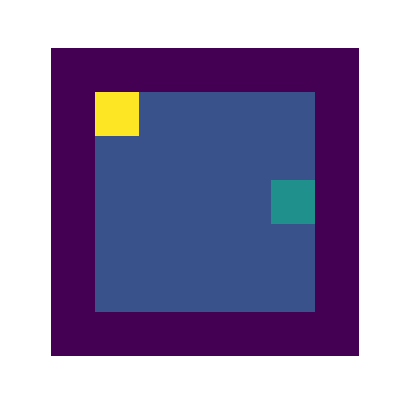

In [ ]:
from evaluate_dqn import run_evaluation, EvaluationConfig

weights_file = str(OUTPUTS['fo_dqn'] / "dqn_fo_final.weights.h5")

eval_config = EvaluationConfig(
    board_size=7,
    n_actions=4,
    max_steps=1000,
    n_episodes_per_seed=20,
    seeds=(42, 100, 2024, 777, 99),
    greedy=True,
    save_gif=True,
    gif_filename=str(OUTPUTS['fo_dqn'] / "fo_agent_gameplay.gif")
)

print(f"Evaluating FO DQN Agent...")
fo_report = run_evaluation(weights_path=weights_file, cfg=eval_config)

metrics = fo_report["overall"]
print("\n" + "="*50)
print("FO DQN - ROBUSTNESS ANALYSIS")
print("="*50)
print(f"Episodes: {metrics['episodes']}")
print(f"Avg Reward: {metrics['reward_mean']:.2f} ± {metrics['reward_std']:.2f}")
print(f"95% CI: [{metrics['reward_mean'] - metrics['reward_ci95']:.2f}, "
      f"{metrics['reward_mean'] + metrics['reward_ci95']:.2f}]")
print(f"Fruit Rate: {metrics['fruit_rate_mean']:.4f}")
print(f"Crash Rate: {metrics['safety_event_rate_mean']:.4f}")

from IPython.display import Image, display
display(Image(filename=str(OUTPUTS['fo_dqn'] / "fo_agent_gameplay.gif")))

### Double DQN vs Standard DQN 

Compare Double DQN with standard DQN to demonstrate the benefit of reducing overestimation bias. Both agents are trained under identical conditions.


>>> Avvio Training DDQN (Fully Observable)...


DDQN Training: 100%|██████████| 10000/10000 [09:28<00:00, 17.60it/s]



>>> Avvio Training Standard DQN (Fully Observable)...


Standard DQN Training: 100%|██████████| 10000/10000 [09:47<00:00, 17.02it/s]



Risultati Finali (Media ultimi 500 step):
Standard DQN: 0.1208
Double DQN:   0.1226


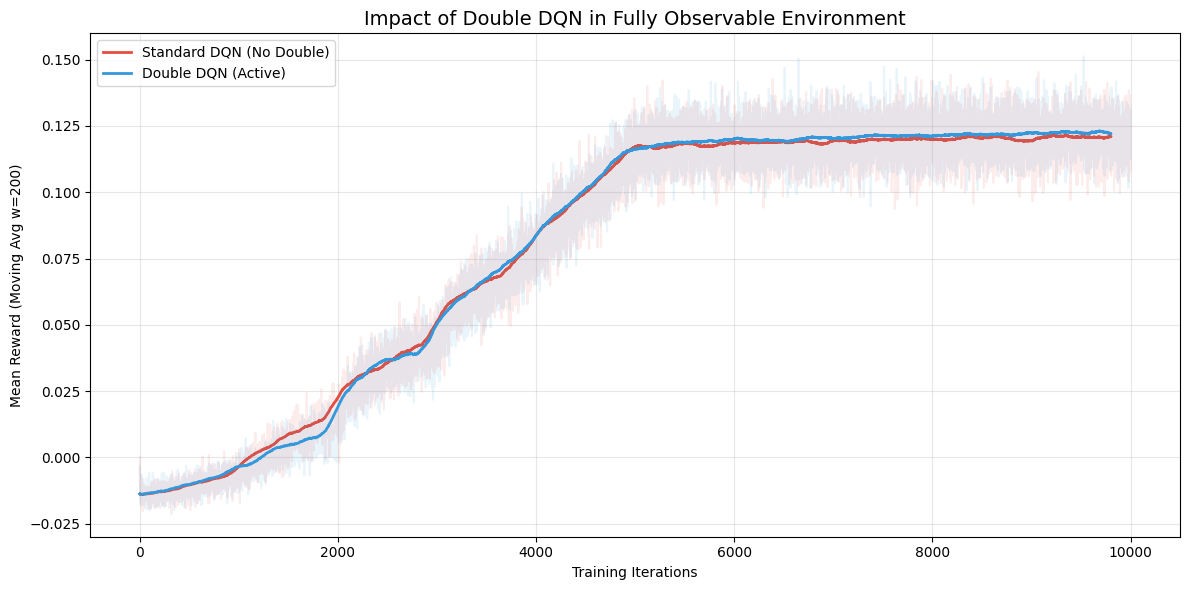

In [ ]:
def run_fo_training_ablation(use_double_dqn, iterations=10000, n_boards=1000):
    """Train FO agent with configurable Double DQN flag."""
    
    config = DQNConfig(
        gamma=GAMMA,
        learning_rate=1e-4,
        batch_size=256,
        buffer_capacity=200_000,
        warmup_steps=1000,
        epsilon_decay_steps=iterations // 2,
        use_double_dqn=use_double_dqn
    )
    
    env = get_env_fo(n=n_boards)
    agent = DQNAgent(state_shape=STATE_SHAPE_FO, n_actions=N_ACTIONS, config=config)
    
    rewards_history = []
    for _ in trange(iterations, desc="DDQN" if use_double_dqn else "DQN"):
        metrics = agent.train_on_env_step(env)
        rewards_history.append(metrics["mean_reward"])
    
    return rewards_history

# Train both variants
print("Training standard DQN...")
dqn_rewards = run_fo_training_ablation(use_double_dqn=False, iterations=FO_ITERATIONS)

print("Training Double DQN...")
ddqn_rewards = run_fo_training_ablation(use_double_dqn=True, iterations=FO_ITERATIONS)

# Plot comparison
def plot_dqn_variants(dqn_data, ddqn_data, output_path, window=200):
    """Compare DQN vs Double DQN learning curves."""
    
    def smooth(data, w):
        return np.convolve(data, np.ones(w) / w, mode='valid')

    plt.figure(figsize=(12, 6))
    plt.plot(smooth(dqn_data, window), color='#e74c3c', label='Standard DQN', linewidth=2.5)
    plt.plot(dqn_data, color='#e74c3c', alpha=0.1)
    
    plt.plot(smooth(ddqn_data, window), color='#3498db', label='Double DQN', linewidth=2.5)
    plt.plot(ddqn_data, color='#3498db', alpha=0.1)
    
    plt.title("DQN vs Double DQN (Fully Observable)", fontsize=13)
    plt.xlabel("Iterations", fontsize=12)
    plt.ylabel(f"Mean Reward (Moving Avg, window={window})", fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    plt.savefig(str(output_path), dpi=300, bbox_inches='tight')
    print(f"✓ Plot saved: {output_path}")
    plt.show()

plot_dqn_variants(dqn_rewards, ddqn_rewards, OUTPUTS['comparison'] / "dqn_vs_ddqn.pdf")

## Partially Observable (PO) Environment

In this section, we train a **Dueling Double DQN with Frame Stacking** on a $5 \times 5$ local view. The agent must infer velocity and direction from temporal information.

In [15]:
def get_env_po(n=1000):
    """Factory function for partially observable environment."""
    return environments_partially_observable.OriginalSnakeEnvironment(n, BOARD_SIZE, MASK_SIZE)

# PO configuration
PO_ITERATIONS = 15_000

po_config = PODQNConfig(epsilon_decay_steps=PO_ITERATIONS - 3000)

### PO DQN Training

Train the agent with frame stacking ($k=4$) to capture motion information. The local 5×5 view forces the agent to learn reactive policies.

In [16]:
from typing import Callable, List, Dict

def run_po_training(
    env_factory: Callable[[int], object],
    iterations: int = 15_000,
    n_boards: int = 1_000,
    config: PODQNConfig = None,
    output_dir: Path = None
) -> List[Dict]:
    """Train PO DQN agent with frame stacking."""
    
    env = env_factory(n_boards)
    raw_state_shape = tuple(np.asarray(env.to_state()).shape[1:])

    agent = PartiallyObservableDQNAgent(
        raw_state_shape=raw_state_shape,
        n_actions=N_ACTIONS,
        n_boards=n_boards,
        config=config,
    )

    logs = []
    pbar = trange(iterations, desc="PO DQN Training")
    
    for i in pbar:
        metrics = agent.train_on_env_step(env)
        logs.append(metrics)
        
        if i % 10 == 0:
            current_eps = agent.epsilon()
            loss_val = metrics.get("loss")
            loss_str = f"{loss_val:.4f}" if loss_val is not None else "Warmup"
            
            pbar.set_postfix({
                "reward": f"{metrics['mean_reward']:.4f}",
                "loss": loss_str,
                "eps": f"{current_eps:.2f}"
            })
            
        if i > 0 and i % 3000 == 0:
            if output_dir:
                ckpt_path = output_dir / f"po_dqn_ckpt_{i}.weights.h5"
                agent.online_network.save_weights(str(ckpt_path))

    if output_dir:
        final_path = output_dir / "po_dqn_final.weights.h5"
        agent.online_network.save_weights(str(final_path))
        print(f"\n✓ Training complete. Weights saved: {final_path}")
    
    return logs

# PO training configuration
po_config = PODQNConfig(
    gamma=0.99,
    learning_rate=1e-4,
    batch_size=256,
    buffer_capacity=200_000,
    warmup_steps=5_000,
    train_frequency=4,
    target_update_frequency=1_000,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay_steps=12_000,
    gradient_clip_norm=10.0,
    use_double_dqn=True,
    frame_stack=4
)

print("Starting PO DQN Training...")
po_logs = run_po_training(
    env_factory=get_env_po,
    iterations=PO_ITERATIONS,
    n_boards=N_PARALLEL_BOARDS,
    config=po_config,
    output_dir=OUTPUTS['po_dqn']
)

po_rewards = [log["mean_reward"] for log in po_logs]

Starting PO DQN Training...


PO DQN Training: 100%|██████████| 15000/15000 [11:37<00:00, 21.51it/s, reward=0.1176, loss=Warmup, eps=0.05] 


✓ Training complete. Weights saved: results/po_dqn/po_dqn_final.weights.h5


### Performance Evaluation & Visualization

Evaluate the PO DQN agent across multiple seeds. Generate robustness statistics and visualize temporal reward dynamics.

Running Analysis (5 seeds)...


/tmp/ipykernel_12375/3332535052.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=seeds, y=total_rewards, palette="Blues")



Plots saved in PDF format at: eval_results_po


### 1. Robustness Analysis (Reward Distribution)

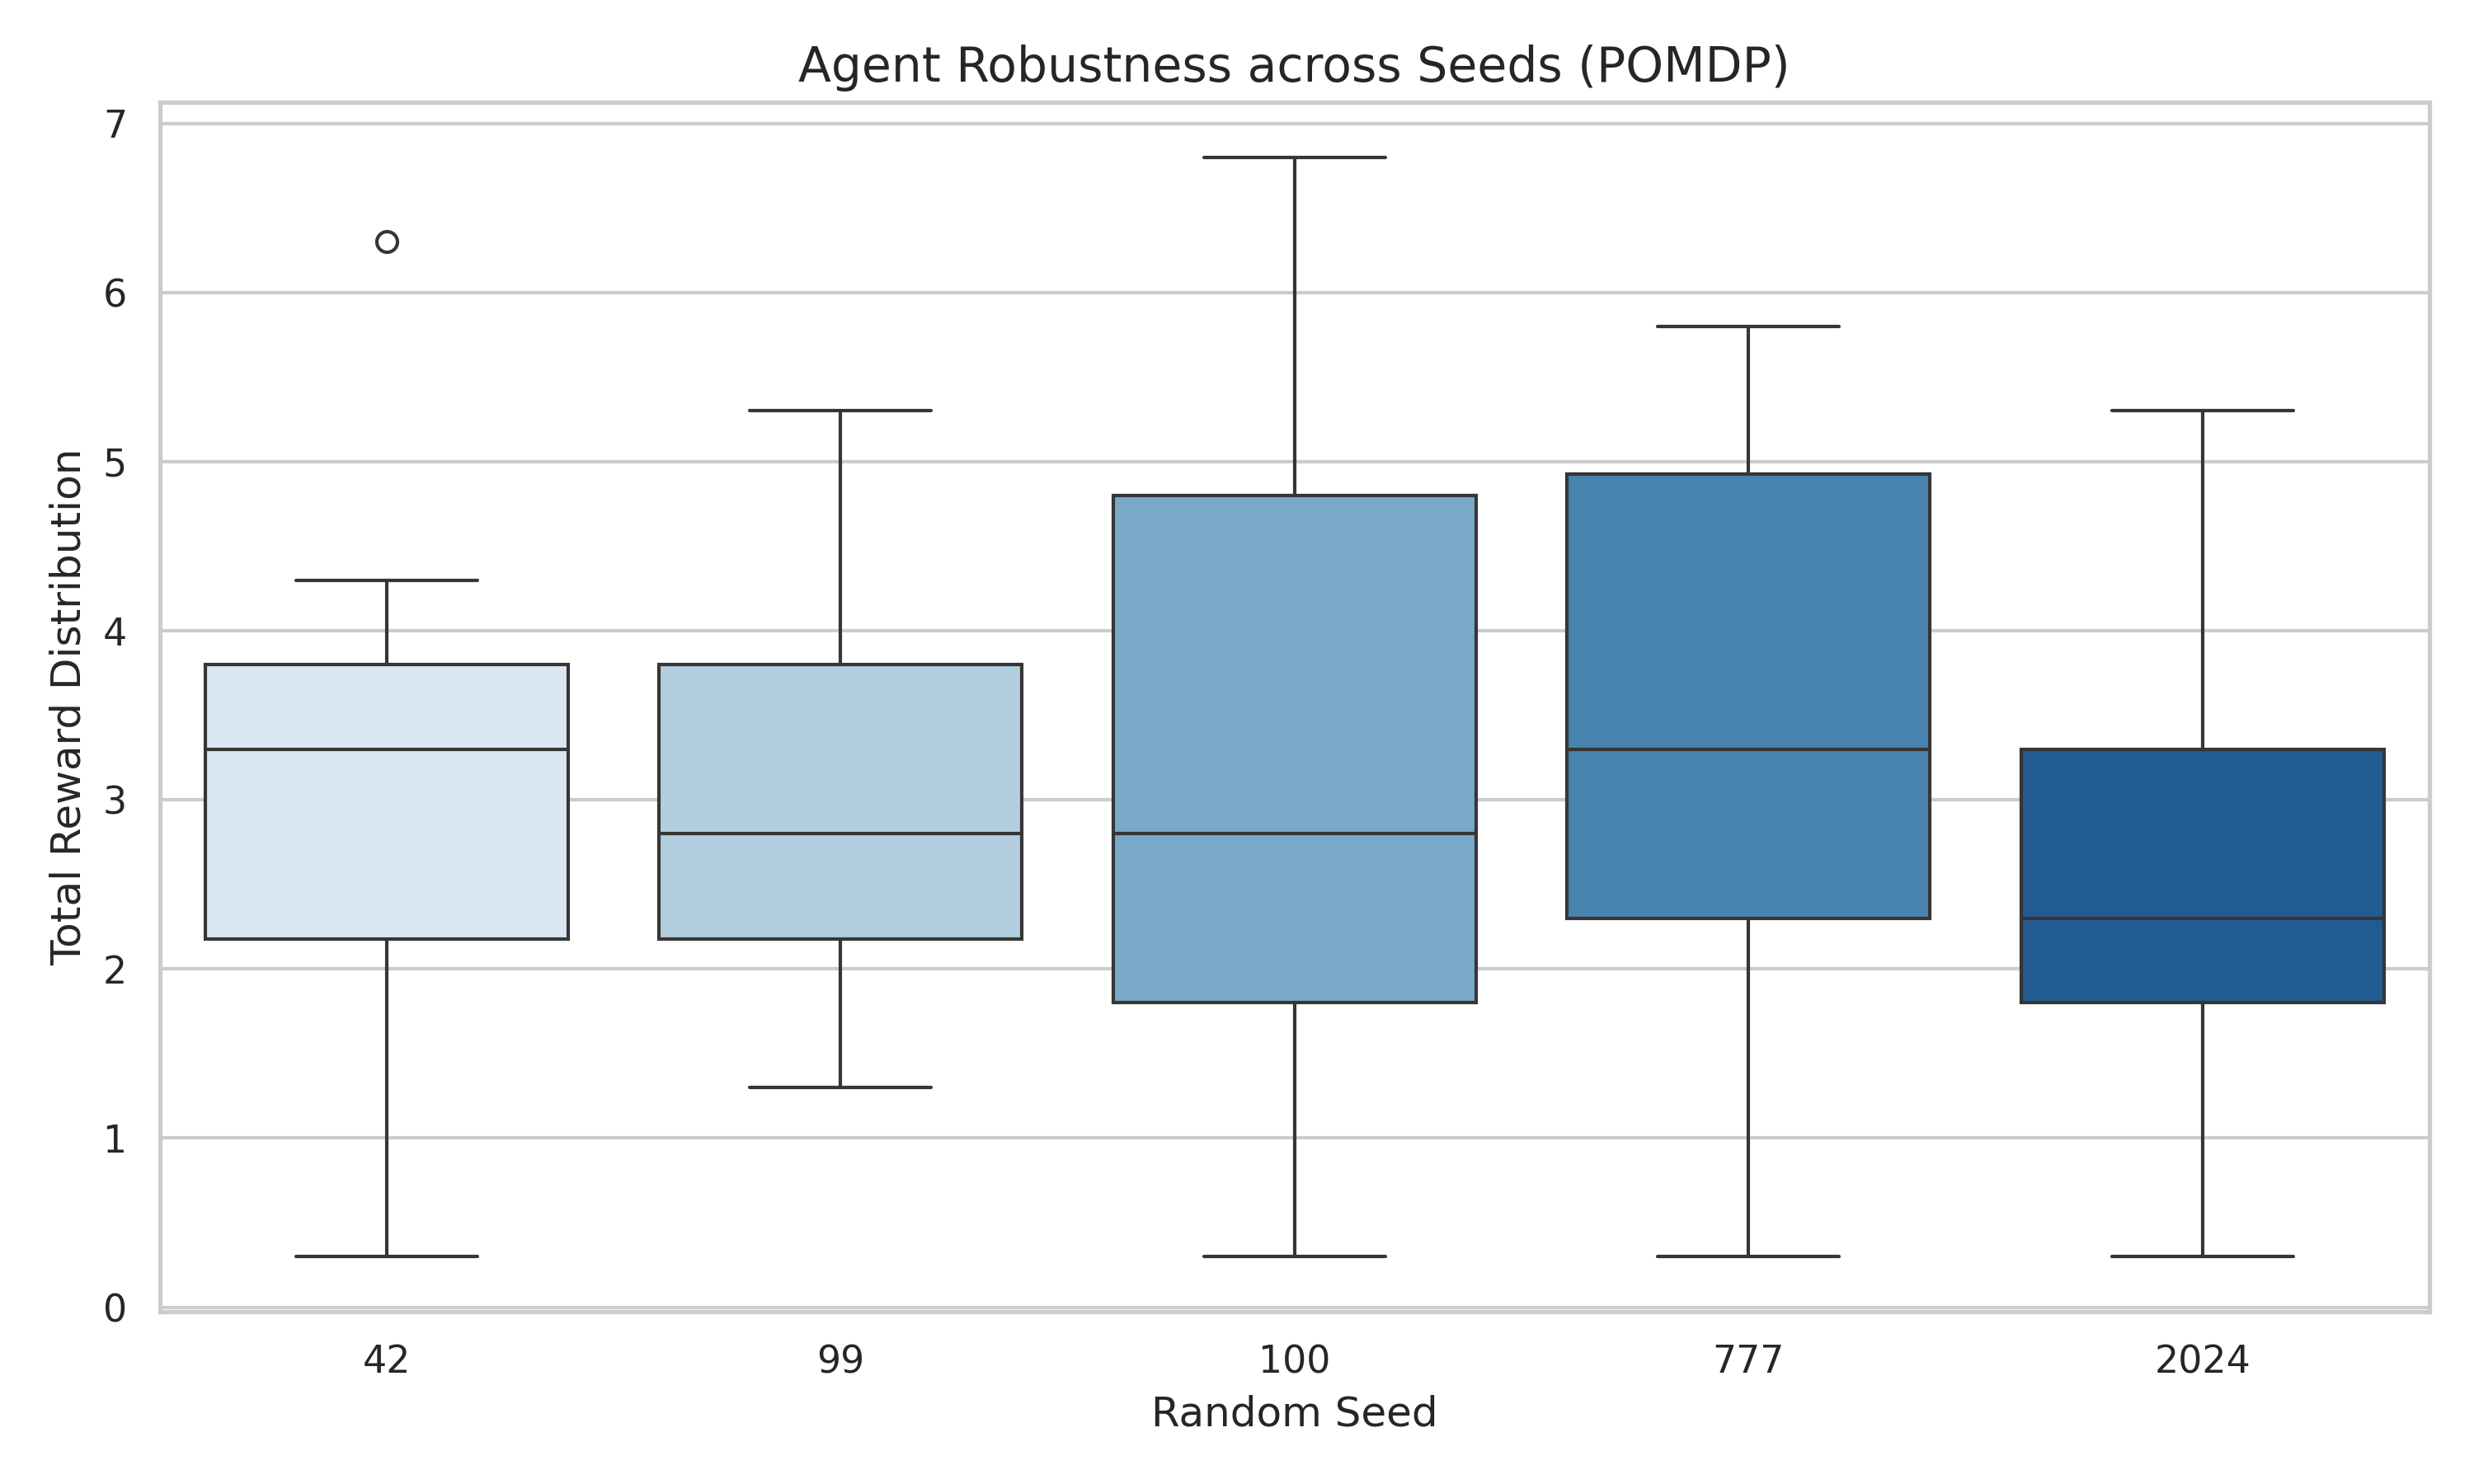

### 2. Temporal Dynamics (Reward Evolution)

> *Shows the agent's ability to survive and collect rewards over time.*

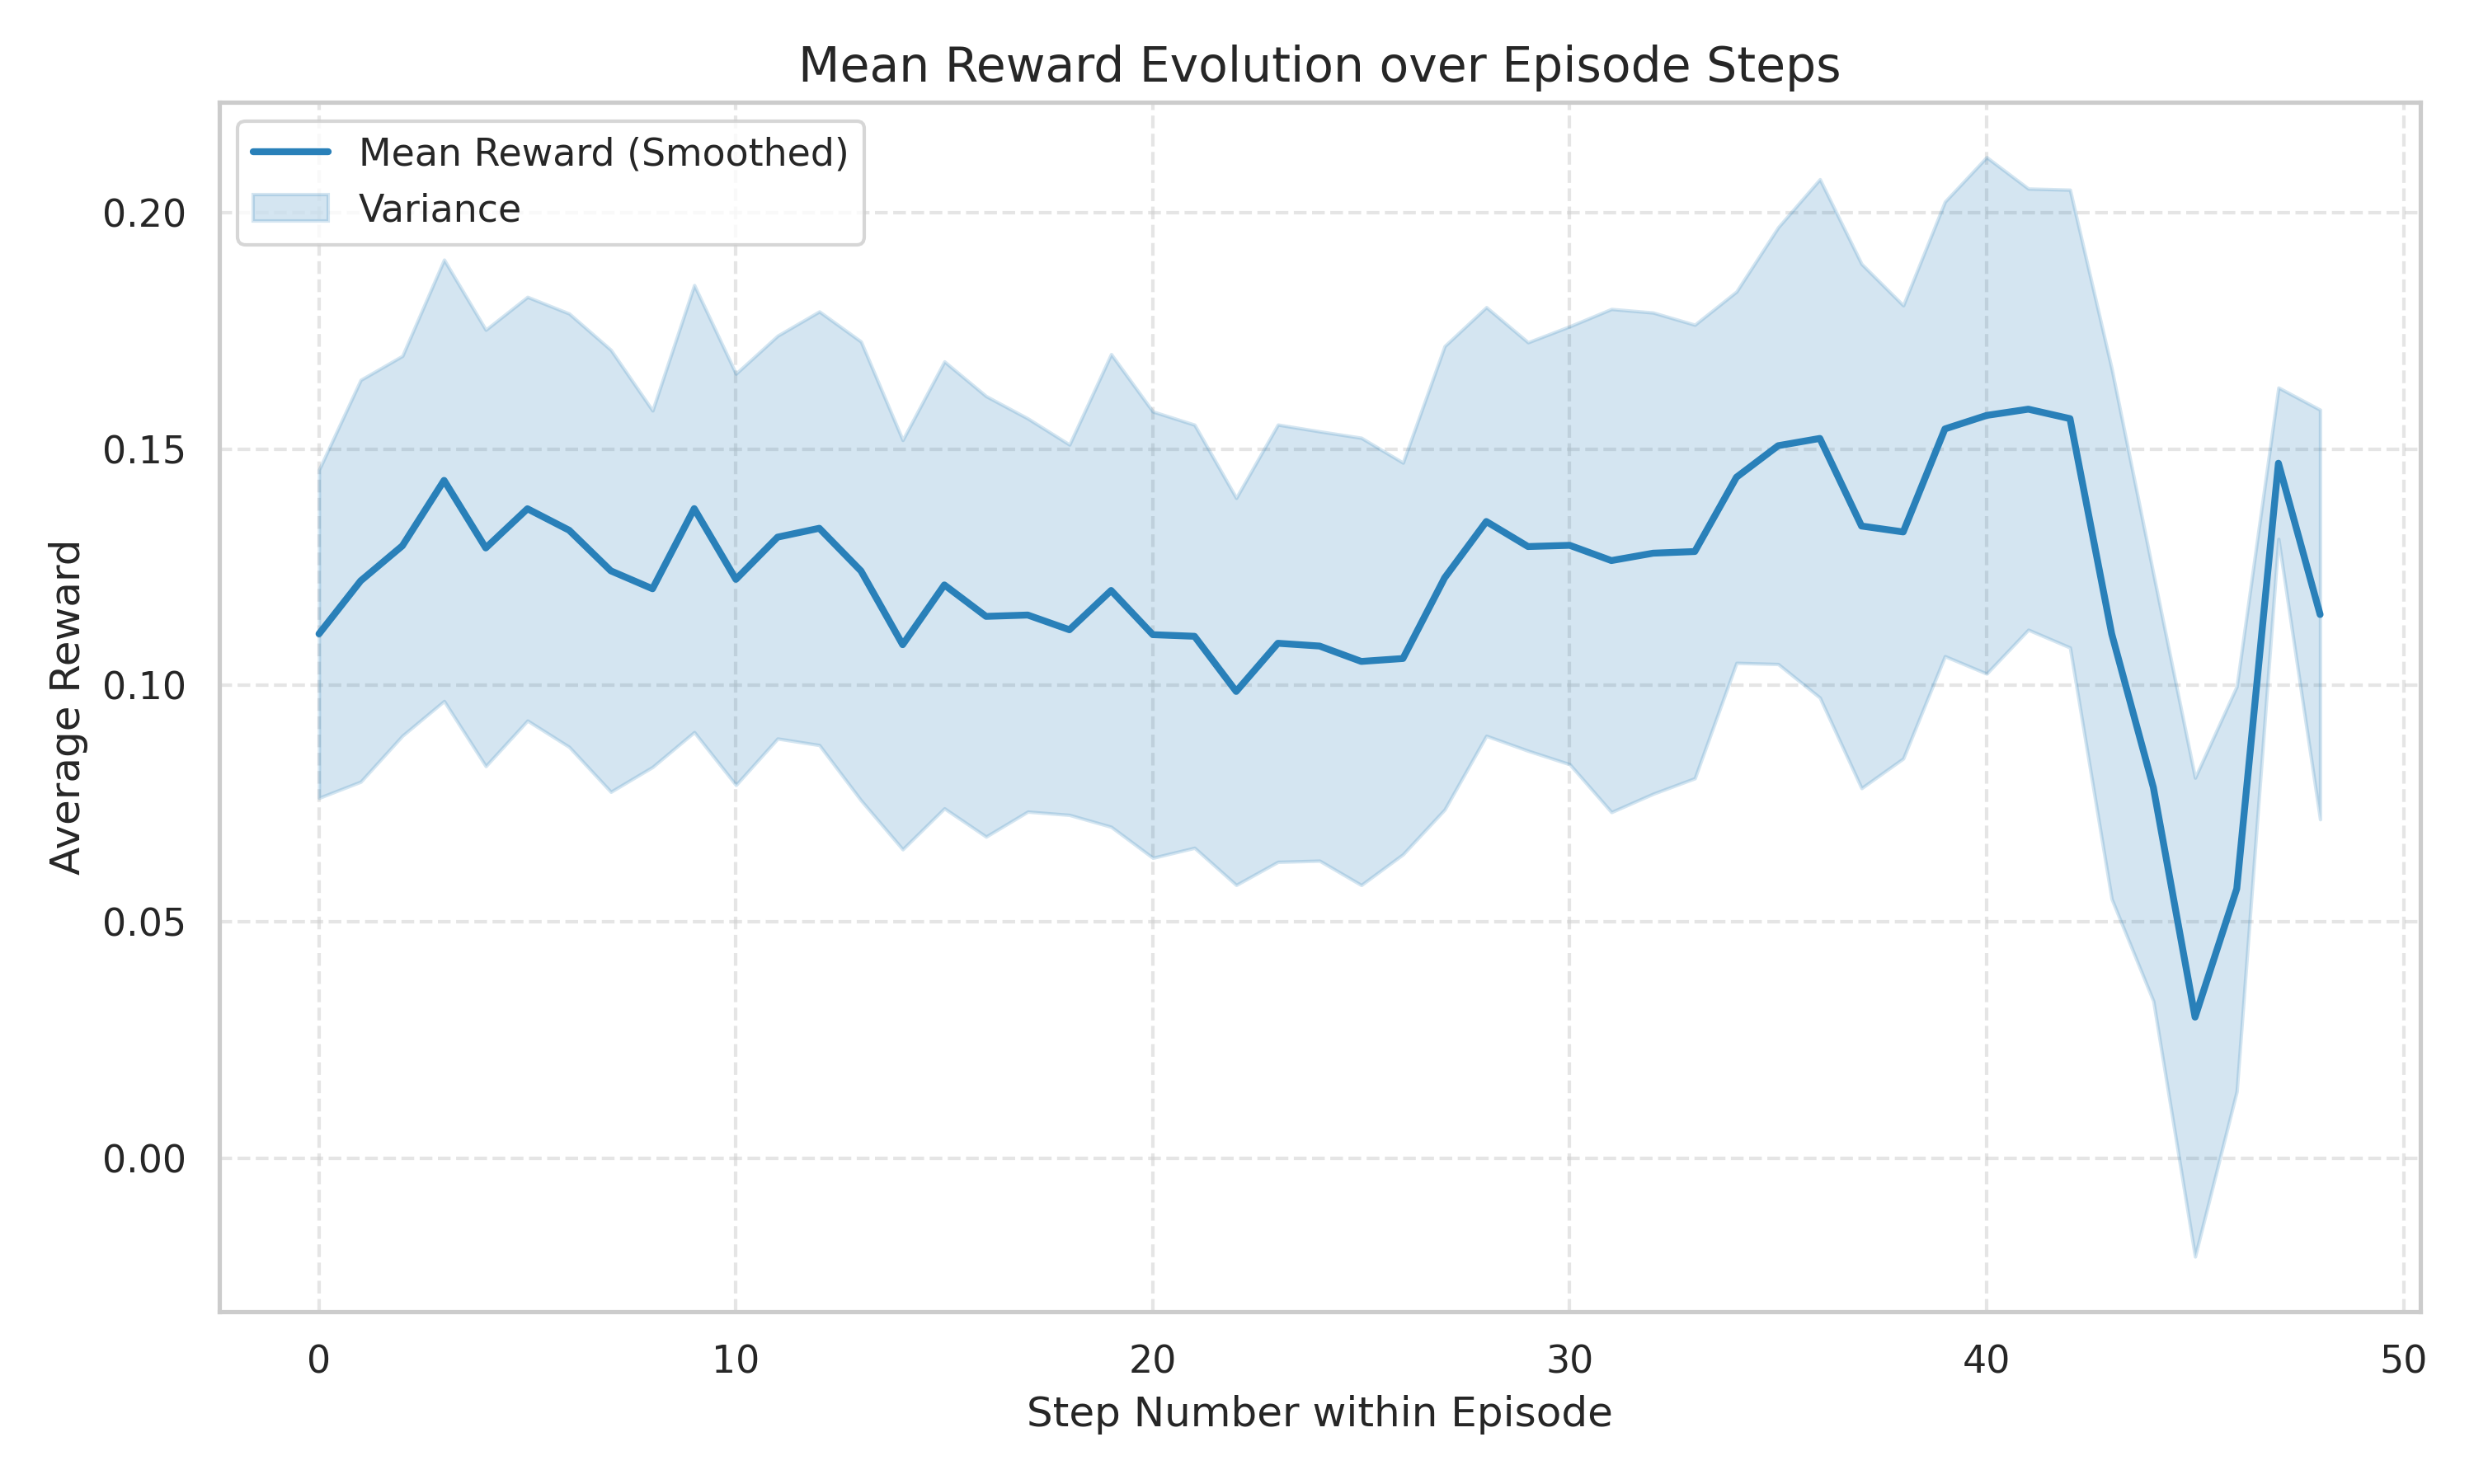

### 3. Best Gameplay Replay

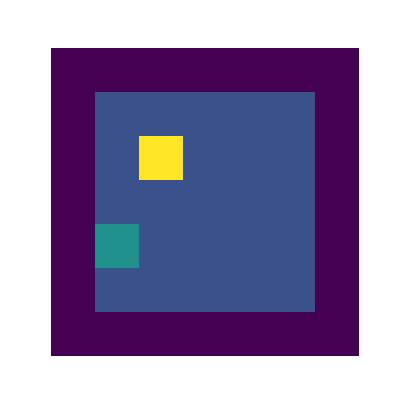

In [5]:
from dataclasses import dataclass
from typing import Sequence
import csv
import json

@dataclass
class EvalConfigPO:
    """Configuration for PO agent evaluation."""
    weights_path: str
    output_dir: Path = OUTPUTS['po_dqn']
    board_size: int = 7
    mask_size: int = 2
    max_steps: int = 500
    n_episodes_per_seed: int = 20
    seeds: Sequence[int] = (42, 100, 2024, 777, 99)
    save_gif: bool = True

def get_env_single(n: int):
    """Factory for single environment (used in evaluation)."""
    return environments_partially_observable.OriginalSnakeEnvironment(n, BOARD_SIZE, MASK_SIZE)

def set_seed(seed: int):
    """Set global random seeds."""
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def evaluate_po_episode(agent, env, max_steps):
    """Run a single episode and collect metrics."""
    raw_state = np.asarray(env.to_state(), dtype=np.float32)
    agent.stacker.reset(raw_state)
    
    total_reward = 0.0
    frames = []
    rewards_per_step = []

    for t in range(max_steps):
        frames.append(env.boards[0].copy())
        current_stacked_state = agent.stacker.buffer
        action = agent.select_actions(current_stacked_state, greedy=True)
        reward_tensor = env.move(action.reshape(-1, 1))
        reward = float(np.asarray(reward_tensor).flatten()[0])
        next_raw_state = np.asarray(env.to_state(), dtype=np.float32)
        agent.stacker.update(next_raw_state)
        
        total_reward += reward
        rewards_per_step.append(reward)
        
        # Check termination conditions
        if (np.isclose(reward, env.HIT_WALL_REWARD) or 
            np.isclose(reward, env.ATE_HIMSELF_REWARD) or 
            np.isclose(reward, env.WIN_REWARD)):
            break
            
    return {
        "total_reward": total_reward,
        "steps": t + 1,
        "frames": frames,
        "rewards_per_step": rewards_per_step
    }

def run_po_evaluation(cfg: EvalConfigPO):
    """Complete evaluation pipeline for PO agent."""
    
    cfg.output_dir.mkdir(parents=True, exist_ok=True)
    
    # Build agent
    env_dummy = get_env_single(1)
    raw_shape = tuple(np.asarray(env_dummy.to_state()).shape[1:])
    agent = PartiallyObservableDQNAgent(raw_shape, N_ACTIONS, 1, 
                                       PODQNConfig(epsilon_start=0.0, epsilon_end=0.0))
    
    # Load weights
    if not os.path.exists(cfg.weights_path):
        print(f"Error: Weights not found at {cfg.weights_path}")
        return
    
    dummy_input = np.zeros((1, *agent.stacked_shape), dtype=np.float32)
    agent.online_network(dummy_input)
    agent.online_network.load_weights(cfg.weights_path)
    
    all_results = []
    all_rewards_per_step = []
    best_gif_reward = -np.inf
    best_gif_frames = []
    
    print(f"Evaluating PO Agent ({len(cfg.seeds)} seeds, {cfg.n_episodes_per_seed} episodes/seed)...")
    
    for seed in cfg.seeds:
        set_seed(seed)
        for ep_idx in range(cfg.n_episodes_per_seed):
            env = get_env_single(1)
            metrics = evaluate_po_episode(agent, env, cfg.max_steps)
            
            all_rewards_per_step.append(metrics["rewards_per_step"])
            all_results.append({
                "seed": seed,
                "episode": ep_idx,
                "total_reward": metrics["total_reward"]
            })
            
            if metrics["total_reward"] > best_gif_reward:
                best_gif_reward = metrics["total_reward"]
                best_gif_frames = metrics["frames"]
    
    # Generate plots
    generate_po_plots(all_results, all_rewards_per_step, cfg.output_dir)
    
    if cfg.save_gif and best_gif_frames:
        from matplotlib.animation import FuncAnimation
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.axis("off")
        img = ax.imshow(best_gif_frames[0], origin="lower")
        
        def update(frame):
            img.set_data(frame)
            return [img]
        
        ani = FuncAnimation(fig, update, frames=best_gif_frames, interval=150, blit=True)
        ani.save(str(cfg.output_dir / "best_po_gameplay.gif"), writer="pillow", fps=6)
        plt.close(fig)

def generate_po_plots(results: List[Dict], rewards_per_step: List, output_dir: Path):
    """Generate robustness and temporal dynamics plots."""
    
    sns.set_theme(style="whitegrid")
    
    # Boxplot: Reward distribution across seeds
    seeds = [r['seed'] for r in results]
    rewards = [r['total_reward'] for r in results]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(x=seeds, y=rewards, palette="Blues", ax=ax)
    ax.set_title("PO Agent Robustness Across Seeds (POMDP)", fontsize=13)
    ax.set_xlabel("Random Seed", fontsize=12)
    ax.set_ylabel("Total Reward per Episode", fontsize=12)
    plt.tight_layout()
    
    plt.savefig(str(output_dir / "po_robustness_boxplot.pdf"), dpi=300, bbox_inches='tight')
    plt.savefig(str(output_dir / "po_robustness_boxplot.png"), dpi=300, bbox_inches='tight')
    plt.close()
    
    # Temporal dynamics: Mean reward evolution
    max_len = max(len(r) for r in rewards_per_step)
    padded = np.full((len(rewards_per_step), max_len), np.nan)
    
    for i, r_list in enumerate(rewards_per_step):
        padded[i, :len(r_list)] = r_list
    
    mean_curve = np.nanmean(padded, axis=0)
    
    window = 5
    if len(mean_curve) > window:
        smooth_mean = np.convolve(mean_curve, np.ones(window) / window, mode='valid')
        x_axis = np.arange(len(smooth_mean))
    else:
        smooth_mean = mean_curve
        x_axis = np.arange(len(mean_curve))
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(x_axis, smooth_mean, color='#2980b9', linewidth=2.5, label='Mean Reward (Smoothed)')
    ax.fill_between(x_axis, smooth_mean * 0.9, smooth_mean * 1.1, 
                     color='#2980b9', alpha=0.2)
    
    ax.set_title("PO Agent: Temporal Reward Evolution", fontsize=13)
    ax.set_xlabel("Step within Episode", fontsize=12)
    ax.set_ylabel("Average Reward", fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    plt.savefig(str(output_dir / "po_temporal_dynamics.pdf"), dpi=300, bbox_inches='tight')
    plt.savefig(str(output_dir / "po_temporal_dynamics.png"), dpi=300, bbox_inches='tight')
    plt.close()

# Execute evaluation
weights_file = str(OUTPUTS['po_dqn'] / "po_dqn_final.weights.h5")

if os.path.exists(weights_file):
    eval_cfg = EvalConfigPO(weights_path=weights_file)
    run_po_evaluation(eval_cfg)
    print("\n✓ Evaluation complete. Results saved to:", OUTPUTS['po_dqn'])
else:
    print(f"Weights file not found: {weights_file}")

## FO vs PO Comparative Analysis

Compare fully observable and partially observable agents to quantify the performance gap. This analysis reveals the cost of information loss.

--- Starting Comparative Analysis Visualization ---
✅ Loaded 100 episodes for FO.
✅ Loaded 100 episodes for PO.

--- Summary Statistics ---
Mean Reward (FO): 132.13
Mean Reward (PO): 2.98
Performance Gap: -97.7%


/tmp/ipykernel_25531/1672939675.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


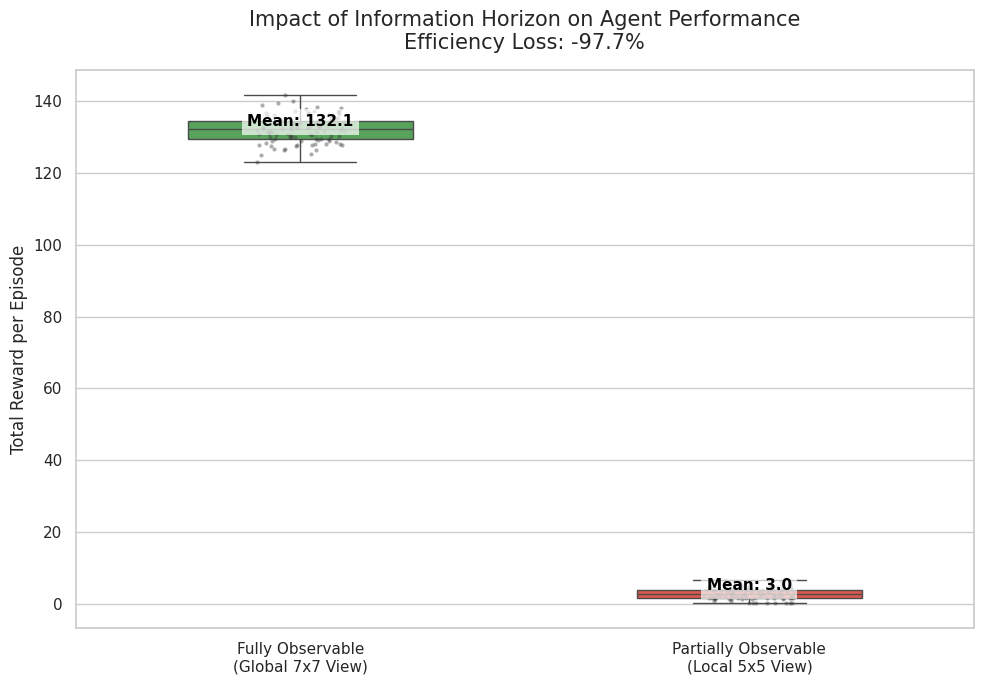

Analysis saved to: final_comparison_analysis.png


In [4]:
import pandas as pd

def plot_fo_po_comparison(output_dir: Path):
    """Generate comparative visualization: FO vs PO performance."""
    
    fo_csv = "evaluation_episodes.csv"  # From FO evaluation
    po_csv = OUTPUTS['po_dqn'] / "evaluation_po_episodes.csv"
    
    if not os.path.exists(fo_csv):
        print(f"Warning: {fo_csv} not found. Skipping FO vs PO comparison.")
        return
    
    # Load data
    df_fo = pd.read_csv(fo_csv)
    df_fo['Type'] = 'Fully Observable'
    
    if os.path.exists(po_csv):
        df_po = pd.read_csv(po_csv)
        df_po['Type'] = 'Partially Observable'
        df_combined = pd.concat([df_fo[['total_reward', 'Type']], 
                                 df_po[['total_reward', 'Type']]], 
                                ignore_index=True)
    else:
        df_combined = df_fo[['total_reward', 'Type']]
    
    # Statistics
    mean_fo = df_fo['total_reward'].mean()
    if os.path.exists(po_csv):
        mean_po = df_po['total_reward'].mean()
        gap_pct = ((mean_fo - mean_po) / mean_fo) * 100
    else:
        gap_pct = 0.0
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 7))
    sns.boxplot(x="Type", y="total_reward", data=df_combined, 
                palette=["#4CAF50", "#F44336"], ax=ax, width=0.5)
    sns.stripplot(x="Type", y="total_reward", data=df_combined, 
                  color=".2", alpha=0.4, size=3, jitter=True, ax=ax)
    
    ax.set_title(f"Information Horizon Impact on Performance\nPerformance Gap: -{gap_pct:.1f}%", 
                 fontsize=14)
    ax.set_ylabel("Total Reward per Episode", fontsize=12)
    ax.set_xlabel("")
    
    # Annotate means
    if os.path.exists(po_csv):
        for i, mean_val in enumerate([mean_fo, mean_po]):
            ax.text(i, mean_val, f'μ={mean_val:.1f}', ha='center', va='bottom',
                   fontweight='bold', fontsize=11,
                   bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    
    plt.tight_layout()
    plt.savefig(str(output_dir / "fo_vs_po_comparison.pdf"), dpi=300, bbox_inches='tight')
    plt.savefig(str(output_dir / "fo_vs_po_comparison.png"), dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"✓ Comparison plot saved to {output_dir}")

plot_fo_po_comparison(OUTPUTS['comparison'])

## PPO Agent with LSTM Memory (Bonus)

Implement a **Policy Gradient agent** with recurrent memory to solve the POMDP by learning a belief state. This is the most sophisticated architecture.

**Note:** Full training requires ~3 days on CPU. Pre-trained weights are available.

In [ ]:
# Environment parameters
BOARD_SIZE = 7
MASK_SIZE = 2
N_BOARDS = 8  # Parallel environments
MAX_EPISODE_STEPS = 500

# Training parameters
N_ITERATIONS = 2000
STEPS_PER_ITERATION = 512
LOG_INTERVAL = 10
SAVE_INTERVAL = 100
PLOT_INTERVAL = 50

# PPO hyperparameters
ppo_config = PPOConfig(
    gamma=0.99,
    lambda_gae=0.95,
    clip_ratio=0.2,
    entropy_coef=0.01,
    value_coef=0.5,
    learning_rate=3e-4,
    max_grad_norm=0.5,
    n_epochs=4,
    batch_size=64,
    lstm_units=128,
    dense_units=256
)

# Paths
CHECKPOINT_DIR = "ppo_checkpoints"
FINAL_WEIGHTS = "ppo_snake_final.weights.h5"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("✓ Configuration complete")

✓ Imports & Configuration for PPO
TensorFlow version: 2.20.0
GPU Available: False

✓ PPO Configuration ready.
  Iterations: 2000
  Parallel boards: 8
  Output directory: results/ppo


In [20]:
# Rollout buffer for trajectory collection

class RolloutBuffer:
    """Stores experience tuples for PPO advantage estimation."""
    
    def __init__(self):
        self.states = []
        self.actions = []
        self.log_probs = []
        self.rewards = []
        self.values = []
        self.dones = []
    
    def add(self, state, action, log_prob, reward, value, done):
        self.states.append(state.copy())
        self.actions.append(action)
        self.log_probs.append(log_prob)
        self.rewards.append(reward)
        self.values.append(value)
        self.dones.append(done)
    
    def get(self):
        return (
            np.array(self.states, dtype=np.float32),
            np.array(self.actions, dtype=np.int32),
            np.array(self.log_probs, dtype=np.float32),
            np.array(self.rewards, dtype=np.float32),
            np.array(self.values, dtype=np.float32),
            np.array(self.dones, dtype=np.float32)
        )
    
    def clear(self):
        self.states.clear()
        self.actions.clear()
        self.log_probs.clear()
        self.rewards.clear()
        self.values.clear()
        self.dones.clear()

print("✓ RolloutBuffer defined")

✓ RolloutBuffer defined


### PPO Training (Computationally Intensive)

**Skip this cell if only interested in evaluation.** Training takes ~3 days on CPU.

In [25]:
# Helper Class
class RolloutBuffer:
    """Stores trajectories for PPO update."""
    
    def __init__(self):
        self.states = []
        self.actions = []
        self.log_probs = []
        self.rewards = []
        self.values = []
        self.dones = []
    
    def add(self, state, action, log_prob, reward, value, done):
        self.states.append(state.copy())
        self.actions.append(action)
        self.log_probs.append(log_prob)
        self.rewards.append(reward)
        self.values.append(value)
        self.dones.append(done)
    
    def get(self):
        return (
            np.array(self.states, dtype=np.float32),
            np.array(self.actions, dtype=np.int32),
            np.array(self.log_probs, dtype=np.float32),
            np.array(self.rewards, dtype=np.float32),
            np.array(self.values, dtype=np.float32),
            np.array(self.dones, dtype=np.float32)
        )
    
    def clear(self):
        self.states.clear()
        self.actions.clear()
        self.log_probs.clear()
        self.rewards.clear()
        self.values.clear()
        self.dones.clear()

print("✓ Helper classes defined")

✓ Helper classes defined


In [26]:
# Create environment
env = environments_partially_observable.OriginalSnakeEnvironment(
    N_BOARDS, BOARD_SIZE, MASK_SIZE
)

raw_state = np.asarray(env.to_state(), dtype=np.float32)
raw_state_shape = raw_state.shape[1:]

print(f"Environment created: {N_BOARDS} boards, size {BOARD_SIZE}x{BOARD_SIZE}")
print(f"Raw state shape: {raw_state_shape}")

# Create agent
agent = PPOAgent(
    raw_state_shape=raw_state_shape,
    n_actions=4,
    n_boards=N_BOARDS,
    n_stack=4,
    config=ppo_config
)

print(f"Agent created with stacked shape: {agent.stacked_shape}")
print(f"Model parameters: {agent.model.count_params():,}")

# Initialize stackers for each board
stackers = [agent.stacker.__class__(raw_state_shape, 4) for _ in range(N_BOARDS)]
for i, stacker in enumerate(stackers):
    stacker.reset(raw_state[i])

print("✓ Environment and agent initialized")

Environment created: 8 boards, size 7x7
Raw state shape: (5, 5, 4)
Agent created with stacked shape: (4, 5, 5, 4)
Model parameters: 1,021,349
✓ Environment and agent initialized


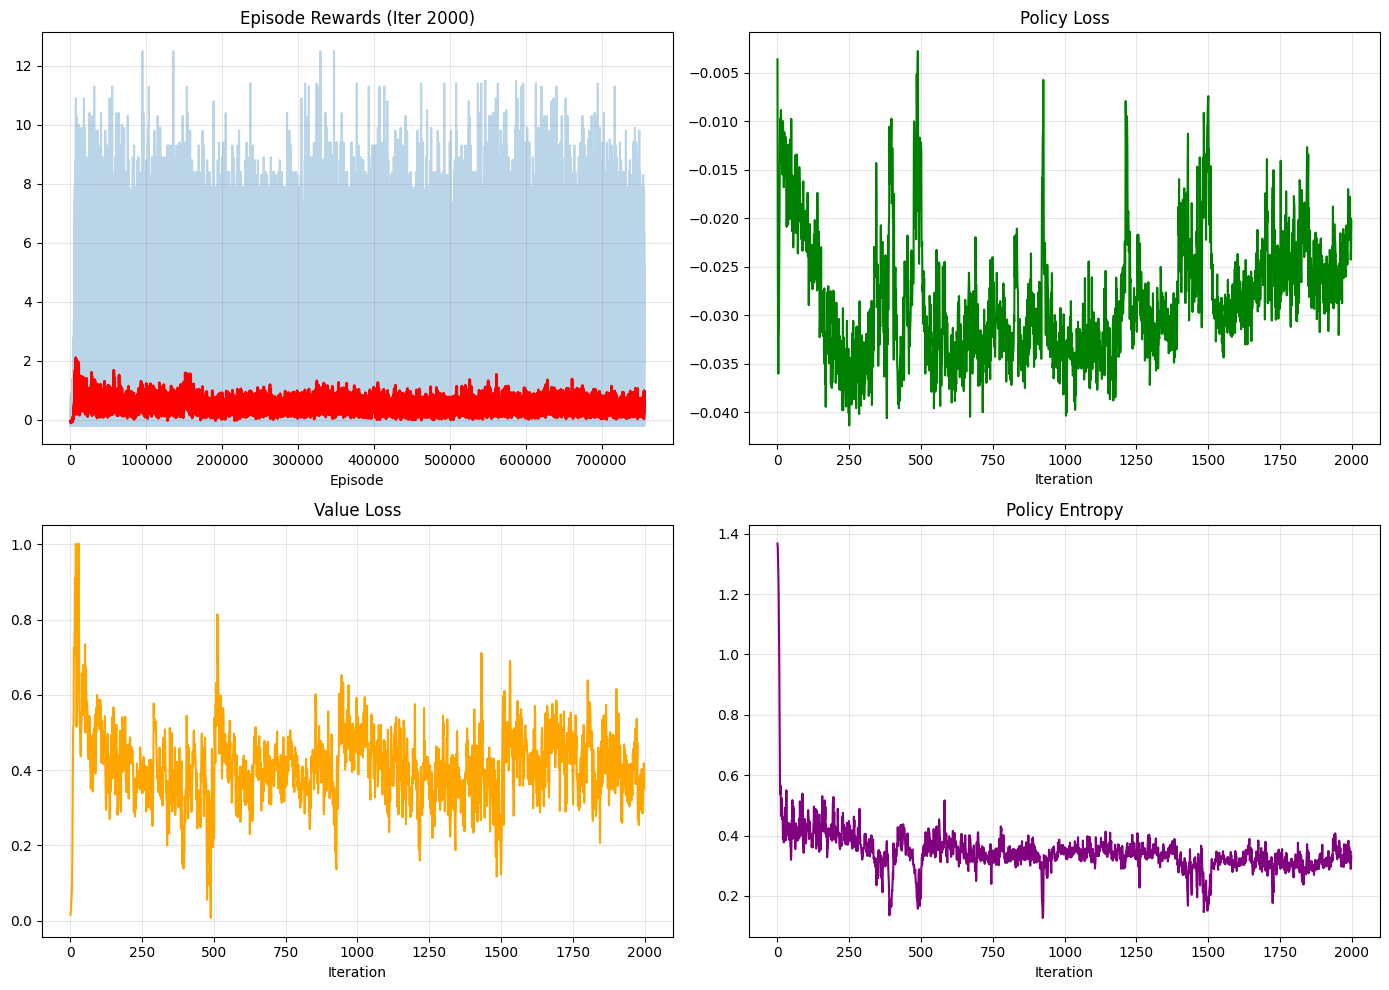

✓ Checkpoint saved: ppo_checkpoints/ppo_iter_2000.weights.h5

✓ Training complete! Weights saved: ppo_snake_final.weights.h5


In [ ]:
# Training Procedure

episode_rewards = []
episode_lengths = []
policy_losses = []
value_losses = []
entropies = []
kl_divergences = []

# Per-board tracking
board_episode_rewards = [0.0] * N_BOARDS
board_episode_lengths = [0] * N_BOARDS

print("✓ Metrics storage initialized")


print("Starting PPO Training...")
print("=" * 80)

for iteration in range(N_ITERATIONS):
    buffer = RolloutBuffer()
    iter_reward = 0.0
    iter_steps = 0
    
    # Collect trajectories
    for step in range(STEPS_PER_ITERATION):
        # Get stacked states
        states = np.array([stacker.buffer for stacker in stackers], dtype=np.float32)
        
        # Select actions
        actions = []
        log_probs = []
        values = []
        
        for board_idx in range(N_BOARDS):
            action, log_prob, value = agent.select_action(states[board_idx], training=True)
            actions.append(action)
            log_probs.append(log_prob)
            values.append(value)
        
        actions_array = np.array(actions).reshape(-1, 1)
        
        # Environment step
        rewards_tensor = env.move(actions_array)
        rewards = np.asarray(rewards_tensor, dtype=np.float32).flatten()
        
        # Update states
        next_raw_state = np.asarray(env.to_state(), dtype=np.float32)
        
        for board_idx in range(N_BOARDS):
            stackers[board_idx].update(next_raw_state[board_idx])
        
        # Check termination and store transitions
        dones = np.zeros(N_BOARDS, dtype=np.float32)
        
        for board_idx in range(N_BOARDS):
            board_episode_rewards[board_idx] += rewards[board_idx]
            board_episode_lengths[board_idx] += 1
            
            is_terminal = (
                board_episode_lengths[board_idx] >= MAX_EPISODE_STEPS or
                np.isclose(rewards[board_idx], env.HIT_WALL_REWARD) or
                np.isclose(rewards[board_idx], env.ATE_HIMSELF_REWARD) or
                np.isclose(rewards[board_idx], env.WIN_REWARD)
            )
            
            if is_terminal:
                dones[board_idx] = 1.0
                episode_rewards.append(board_episode_rewards[board_idx])
                episode_lengths.append(board_episode_lengths[board_idx])
                
                board_episode_rewards[board_idx] = 0.0
                board_episode_lengths[board_idx] = 0
                stackers[board_idx].reset(next_raw_state[board_idx])
            
            buffer.add(
                states[board_idx],
                actions[board_idx],
                log_probs[board_idx],
                rewards[board_idx],
                values[board_idx],
                dones[board_idx]
            )
        
        iter_reward += np.mean(rewards)
        iter_steps += 1
    
    # Compute GAE
    states, actions, log_probs, rewards, values, dones = buffer.get()
    last_states = np.array([stacker.buffer for stacker in stackers], dtype=np.float32)
    _, _, last_value = agent.select_action(last_states[0], training=False)
    
    advantages, returns = agent.compute_gae(rewards, values, dones, last_value)
    
    # Update policy
    metrics = agent.update(states, actions, log_probs, advantages, returns)
    
    policy_losses.append(metrics['policy_loss'])
    value_losses.append(metrics['value_loss'])
    entropies.append(metrics['entropy'])
    kl_divergences.append(metrics['kl_divergence'])
    
    # Logging
    if (iteration + 1) % LOG_INTERVAL == 0:
        recent_rewards = episode_rewards[-100:] if episode_rewards else [0]
        recent_lengths = episode_lengths[-100:] if episode_lengths else [0]
        
        print(f"\nIteration {iteration + 1}/{N_ITERATIONS}")
        print(f"  Episode Reward (last 100): {np.mean(recent_rewards):.3f} ± {np.std(recent_rewards):.3f}")
        print(f"  Episode Length (last 100): {np.mean(recent_lengths):.1f}")
        print(f"  Policy Loss: {metrics['policy_loss']:.4f}")
        print(f"  Value Loss: {metrics['value_loss']:.4f}")
        print(f"  Entropy: {metrics['entropy']:.4f}")
    
    # Plotting
    if (iteration + 1) % PLOT_INTERVAL == 0:
        clear_output(wait=True)
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # Rewards
        if episode_rewards:
            axes[0, 0].plot(episode_rewards, alpha=0.3)
            window = min(100, len(episode_rewards))
            if len(episode_rewards) >= window:
                ma = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
                axes[0, 0].plot(range(window-1, len(episode_rewards)), ma, 'r-', linewidth=2)
            axes[0, 0].set_title(f'Episode Rewards (Iter {iteration + 1})')
            axes[0, 0].set_xlabel('Episode')
            axes[0, 0].grid(True, alpha=0.3)
        
        axes[0, 1].plot(policy_losses, 'g-')
        axes[0, 1].set_title('Policy Loss')
        axes[0, 1].set_xlabel('Iteration')
        axes[0, 1].grid(True, alpha=0.3)
        
        axes[1, 0].plot(value_losses, 'orange')
        axes[1, 0].set_title('Value Loss')
        axes[1, 0].set_xlabel('Iteration')
        axes[1, 0].grid(True, alpha=0.3)
        
        axes[1, 1].plot(entropies, 'purple')
        axes[1, 1].set_title('Policy Entropy')
        axes[1, 1].set_xlabel('Iteration')
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    # Save checkpoints
    if (iteration + 1) % SAVE_INTERVAL == 0:
        checkpoint_path = f"{CHECKPOINT_DIR}/ppo_iter_{iteration + 1}.weights.h5"
        agent.save_weights(checkpoint_path)
        print(f"✓ Checkpoint saved: {checkpoint_path}")

# Save final weights
agent.save_weights(FINAL_WEIGHTS)
print(f"\n✓ Training complete! Weights saved: {FINAL_WEIGHTS}")


### PPO Results Visualization

Load pre-trained weights and visualize training metrics.

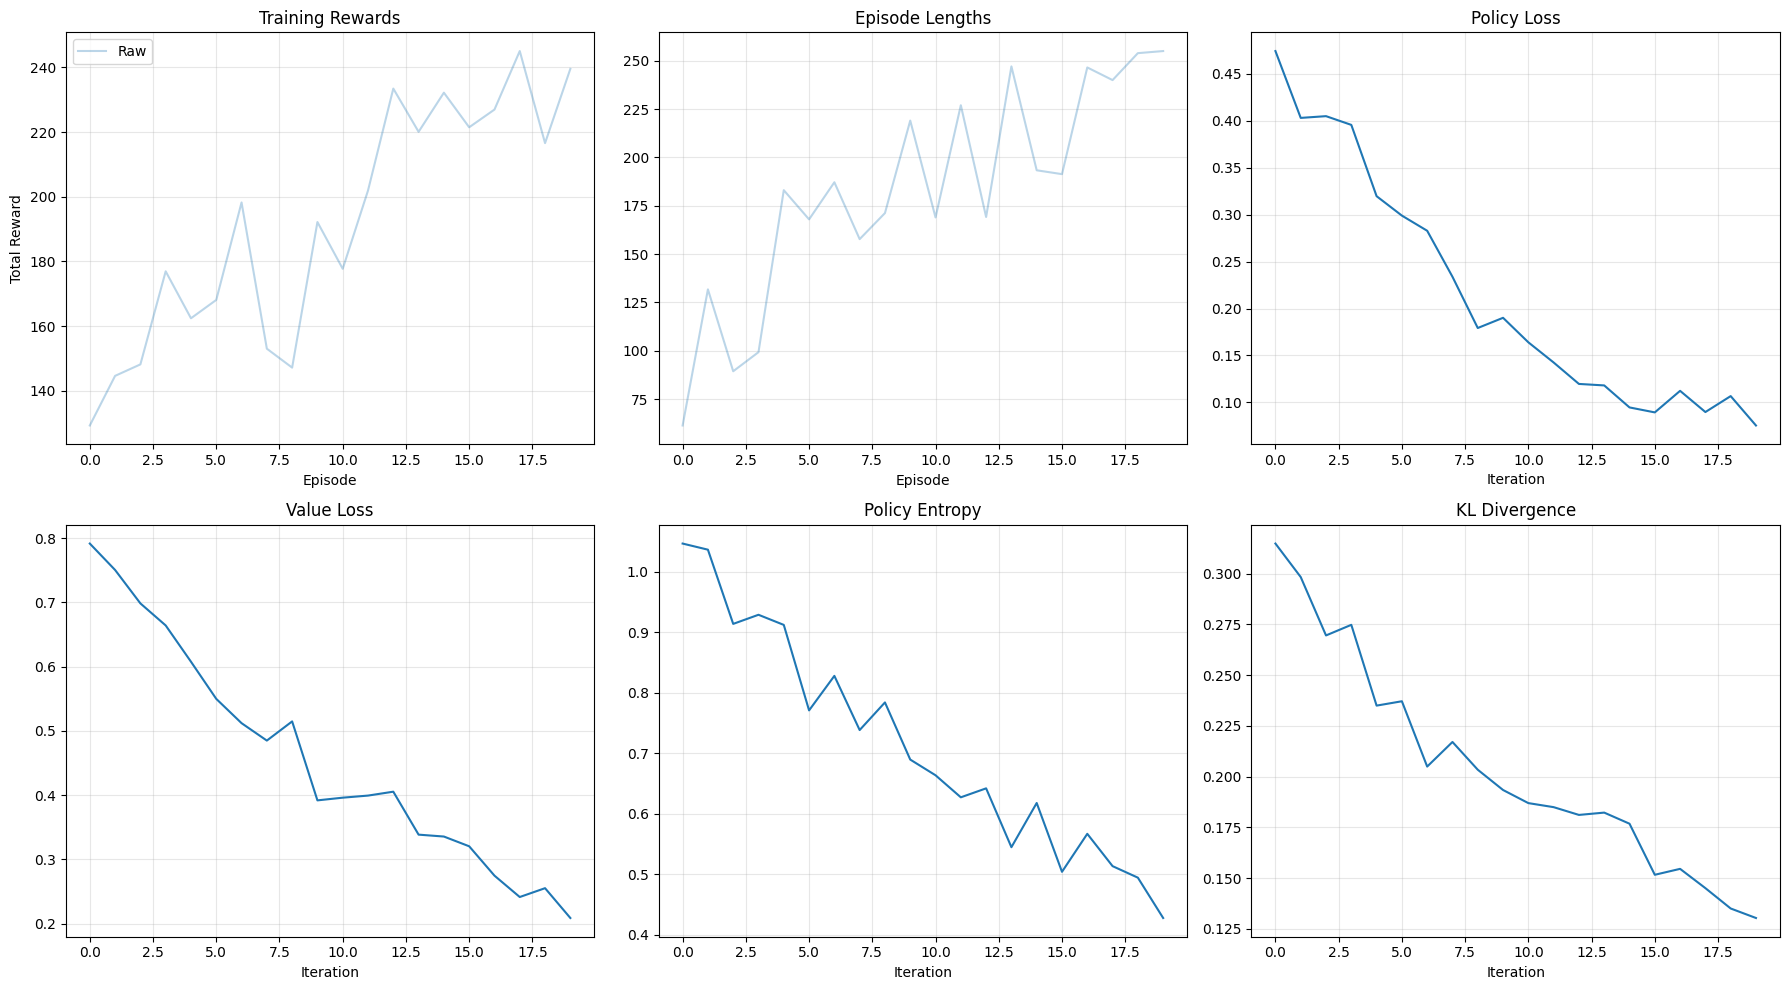


TRAINING STATISTICS
Total Episodes: 20
Final 100 Episodes:
  Mean Reward: 191.757
  Std Reward: 35.713
  Max Reward: 245.025
  Mean Length: 183.0

Best Episode Reward: 245.025
Final Policy Loss: 0.0754
Final Value Loss: 0.2089
Final Entropy: 0.4275


In [27]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Episode rewards
axes[0, 0].plot(episode_rewards, alpha=0.3, label='Raw')
window = 100
if len(episode_rewards) >= window:
    ma = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
    axes[0, 0].plot(range(window-1, len(episode_rewards)), ma, 'r-', linewidth=2, label=f'MA({window})')
axes[0, 0].set_title('Training Rewards')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Total Reward')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Episode lengths
axes[0, 1].plot(episode_lengths, alpha=0.3)
if len(episode_lengths) >= window:
    ma = np.convolve(episode_lengths, np.ones(window)/window, mode='valid')
    axes[0, 1].plot(range(window-1, len(episode_lengths)), ma, 'r-', linewidth=2)
axes[0, 1].set_title('Episode Lengths')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].grid(True, alpha=0.3)

# Policy loss
axes[0, 2].plot(policy_losses)
axes[0, 2].set_title('Policy Loss')
axes[0, 2].set_xlabel('Iteration')
axes[0, 2].grid(True, alpha=0.3)

# Value loss
axes[1, 0].plot(value_losses)
axes[1, 0].set_title('Value Loss')
axes[1, 0].set_xlabel('Iteration')
axes[1, 0].grid(True, alpha=0.3)

# Entropy
axes[1, 1].plot(entropies)
axes[1, 1].set_title('Policy Entropy')
axes[1, 1].set_xlabel('Iteration')
axes[1, 1].grid(True, alpha=0.3)

# KL divergence
axes[1, 2].plot(kl_divergences)
axes[1, 2].set_title('KL Divergence')
axes[1, 2].set_xlabel('Iteration')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ppo_training_final_analysis.pdf', dpi=300)
plt.show()

# Print statistics
print("\n" + "=" * 80)
print("TRAINING STATISTICS")
print("=" * 80)
print(f"Total Episodes: {len(episode_rewards)}")
print(f"Final 100 Episodes:")
print(f"  Mean Reward: {np.mean(episode_rewards[-100:]):.3f}")
print(f"  Std Reward: {np.std(episode_rewards[-100:]):.3f}")
print(f"  Max Reward: {np.max(episode_rewards[-100:]):.3f}")
print(f"  Mean Length: {np.mean(episode_lengths[-100:]):.1f}")
print(f"\nBest Episode Reward: {np.max(episode_rewards):.3f}")
print(f"Final Policy Loss: {policy_losses[-1]:.4f}")
print(f"Final Value Loss: {value_losses[-1]:.4f}")
print(f"Final Entropy: {entropies[-1]:.4f}")